In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Cardiotocographic.csv')

In [3]:
df.shape

(2126, 14)

In [4]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [5]:
### missing values
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [6]:
df.fillna(df.median(),inplace=True)

In [7]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   float64
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   float64
 12  Tendency  2126 non-null   float64
 13  NSP       2126 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [9]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000
mean,133.340204,0.003204,0.009894,0.004391,0.001895,0.000002,0.000173,46.995984,1.364378,10.285964,8.276147,70.395387,0.313246,1.301499
std,11.214379,0.004373,0.067540,0.003340,0.003343,0.000141,0.000836,18.813973,1.173632,21.205041,7.734851,42.720508,0.643186,0.642133
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [10]:
corr=df.corr()
corr

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.062813,0.018807,-0.166229,-0.126563,-0.005432,-0.047650,0.241857,-0.169647,0.210542,-0.003423,-0.118397,0.236730,0.131839
AC,-0.062813,1.000000,0.009768,0.071621,-0.093449,-0.033088,-0.083298,-0.230470,0.132962,-0.269807,-0.104853,0.234549,0.031710,-0.311689
FM,0.018807,0.009768,1.000000,-0.053226,0.009718,0.029916,0.121459,-0.032691,0.017055,-0.011936,-0.006121,0.097282,-0.017819,0.074446
UC,-0.166229,0.071621,-0.053226,1.000000,0.190128,-0.006938,0.070295,-0.181161,0.189406,-0.227304,-0.049452,0.107083,-0.066832,-0.185229
DL,-0.126563,-0.093449,0.009718,0.190128,1.000000,0.058413,0.144717,-0.069361,0.410102,-0.186967,-0.165293,0.408578,-0.023914,0.024879
DS,-0.005432,-0.033088,0.029916,-0.006938,0.058413,1.000000,0.004321,0.008426,0.016026,-0.004335,0.034367,0.040845,-0.015294,0.065411
DP,-0.047650,-0.083298,0.121459,0.070295,0.144717,0.004321,1.000000,0.038119,0.118628,-0.076975,-0.113818,0.175462,-0.129204,0.295057
ASTV,0.241857,-0.230470,-0.032691,-0.181161,-0.069361,0.008426,0.038119,1.000000,-0.293882,0.357497,-0.219709,-0.206931,-0.010855,0.420873
MSTV,-0.169647,0.132962,0.017055,0.189406,0.410102,0.016026,0.118628,-0.293882,1.000000,-0.291935,0.028452,0.432822,-0.038017,-0.095876
ALTV,0.210542,-0.269807,-0.011936,-0.227304,-0.186967,-0.004335,-0.076975,0.357497,-0.291935,1.000000,-0.107200,-0.345732,0.038234,0.366454


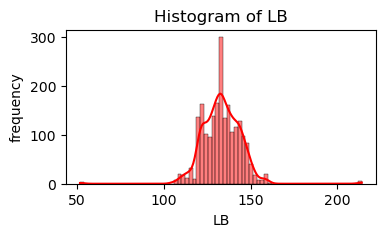

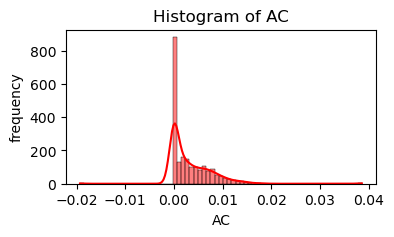

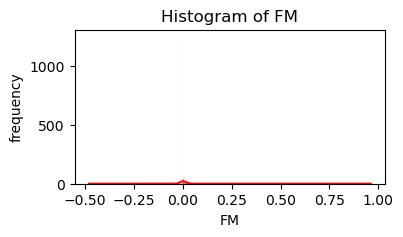

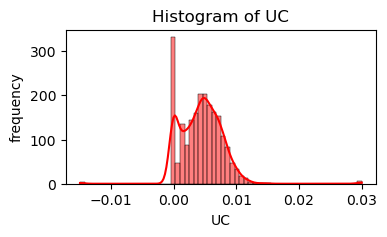

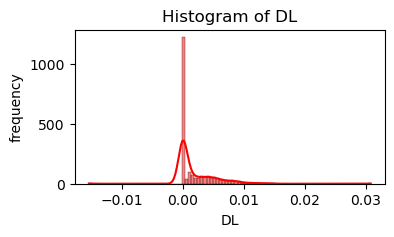

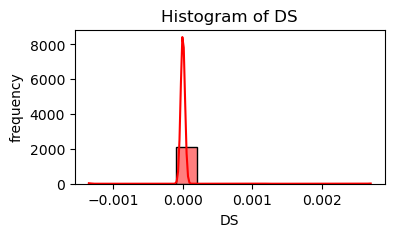

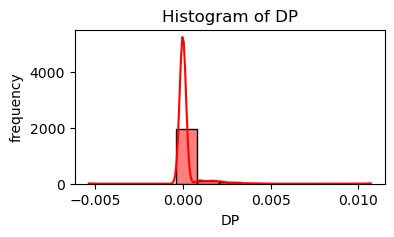

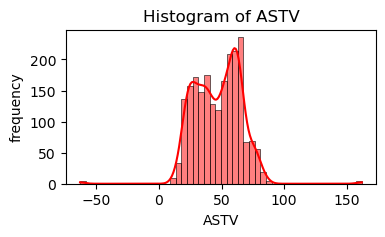

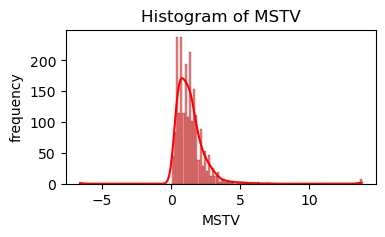

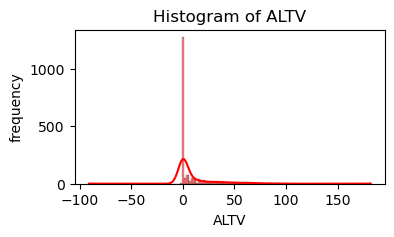

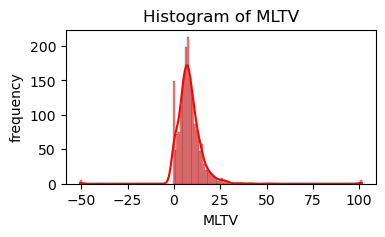

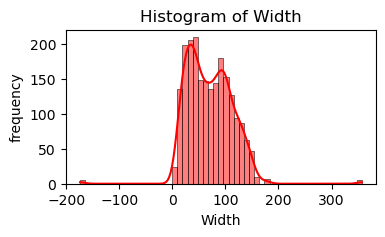

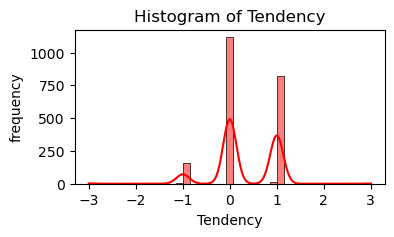

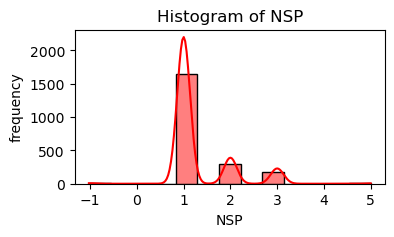

In [11]:
#### Histogram
for col in df.columns:
    plt.figure(figsize=(4,2))
    sns.histplot(df[col],kde=True,color='red',edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.show()

In [12]:
### there are no categorical variablrs

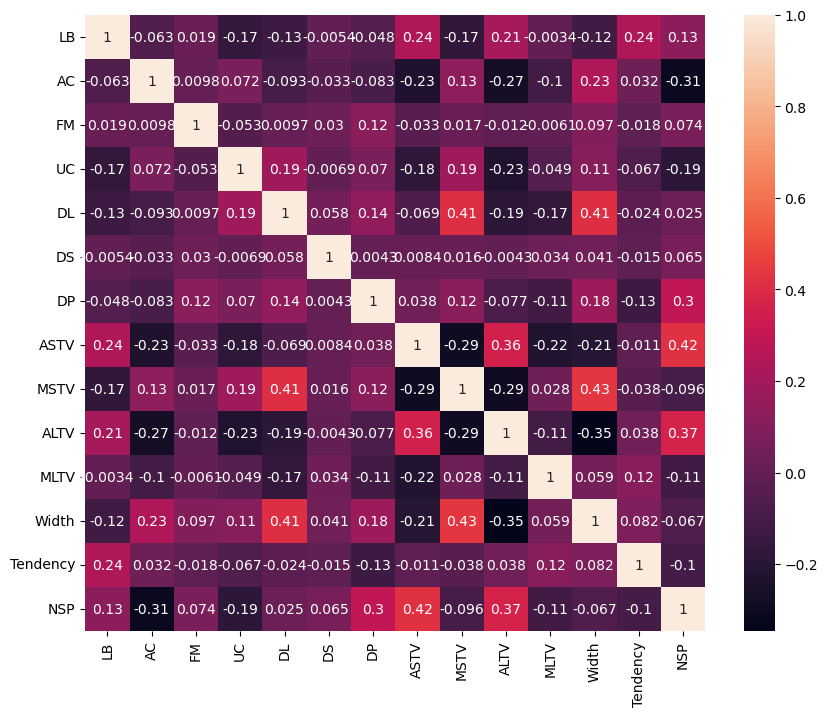

In [13]:
### correlation heat map
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.show();

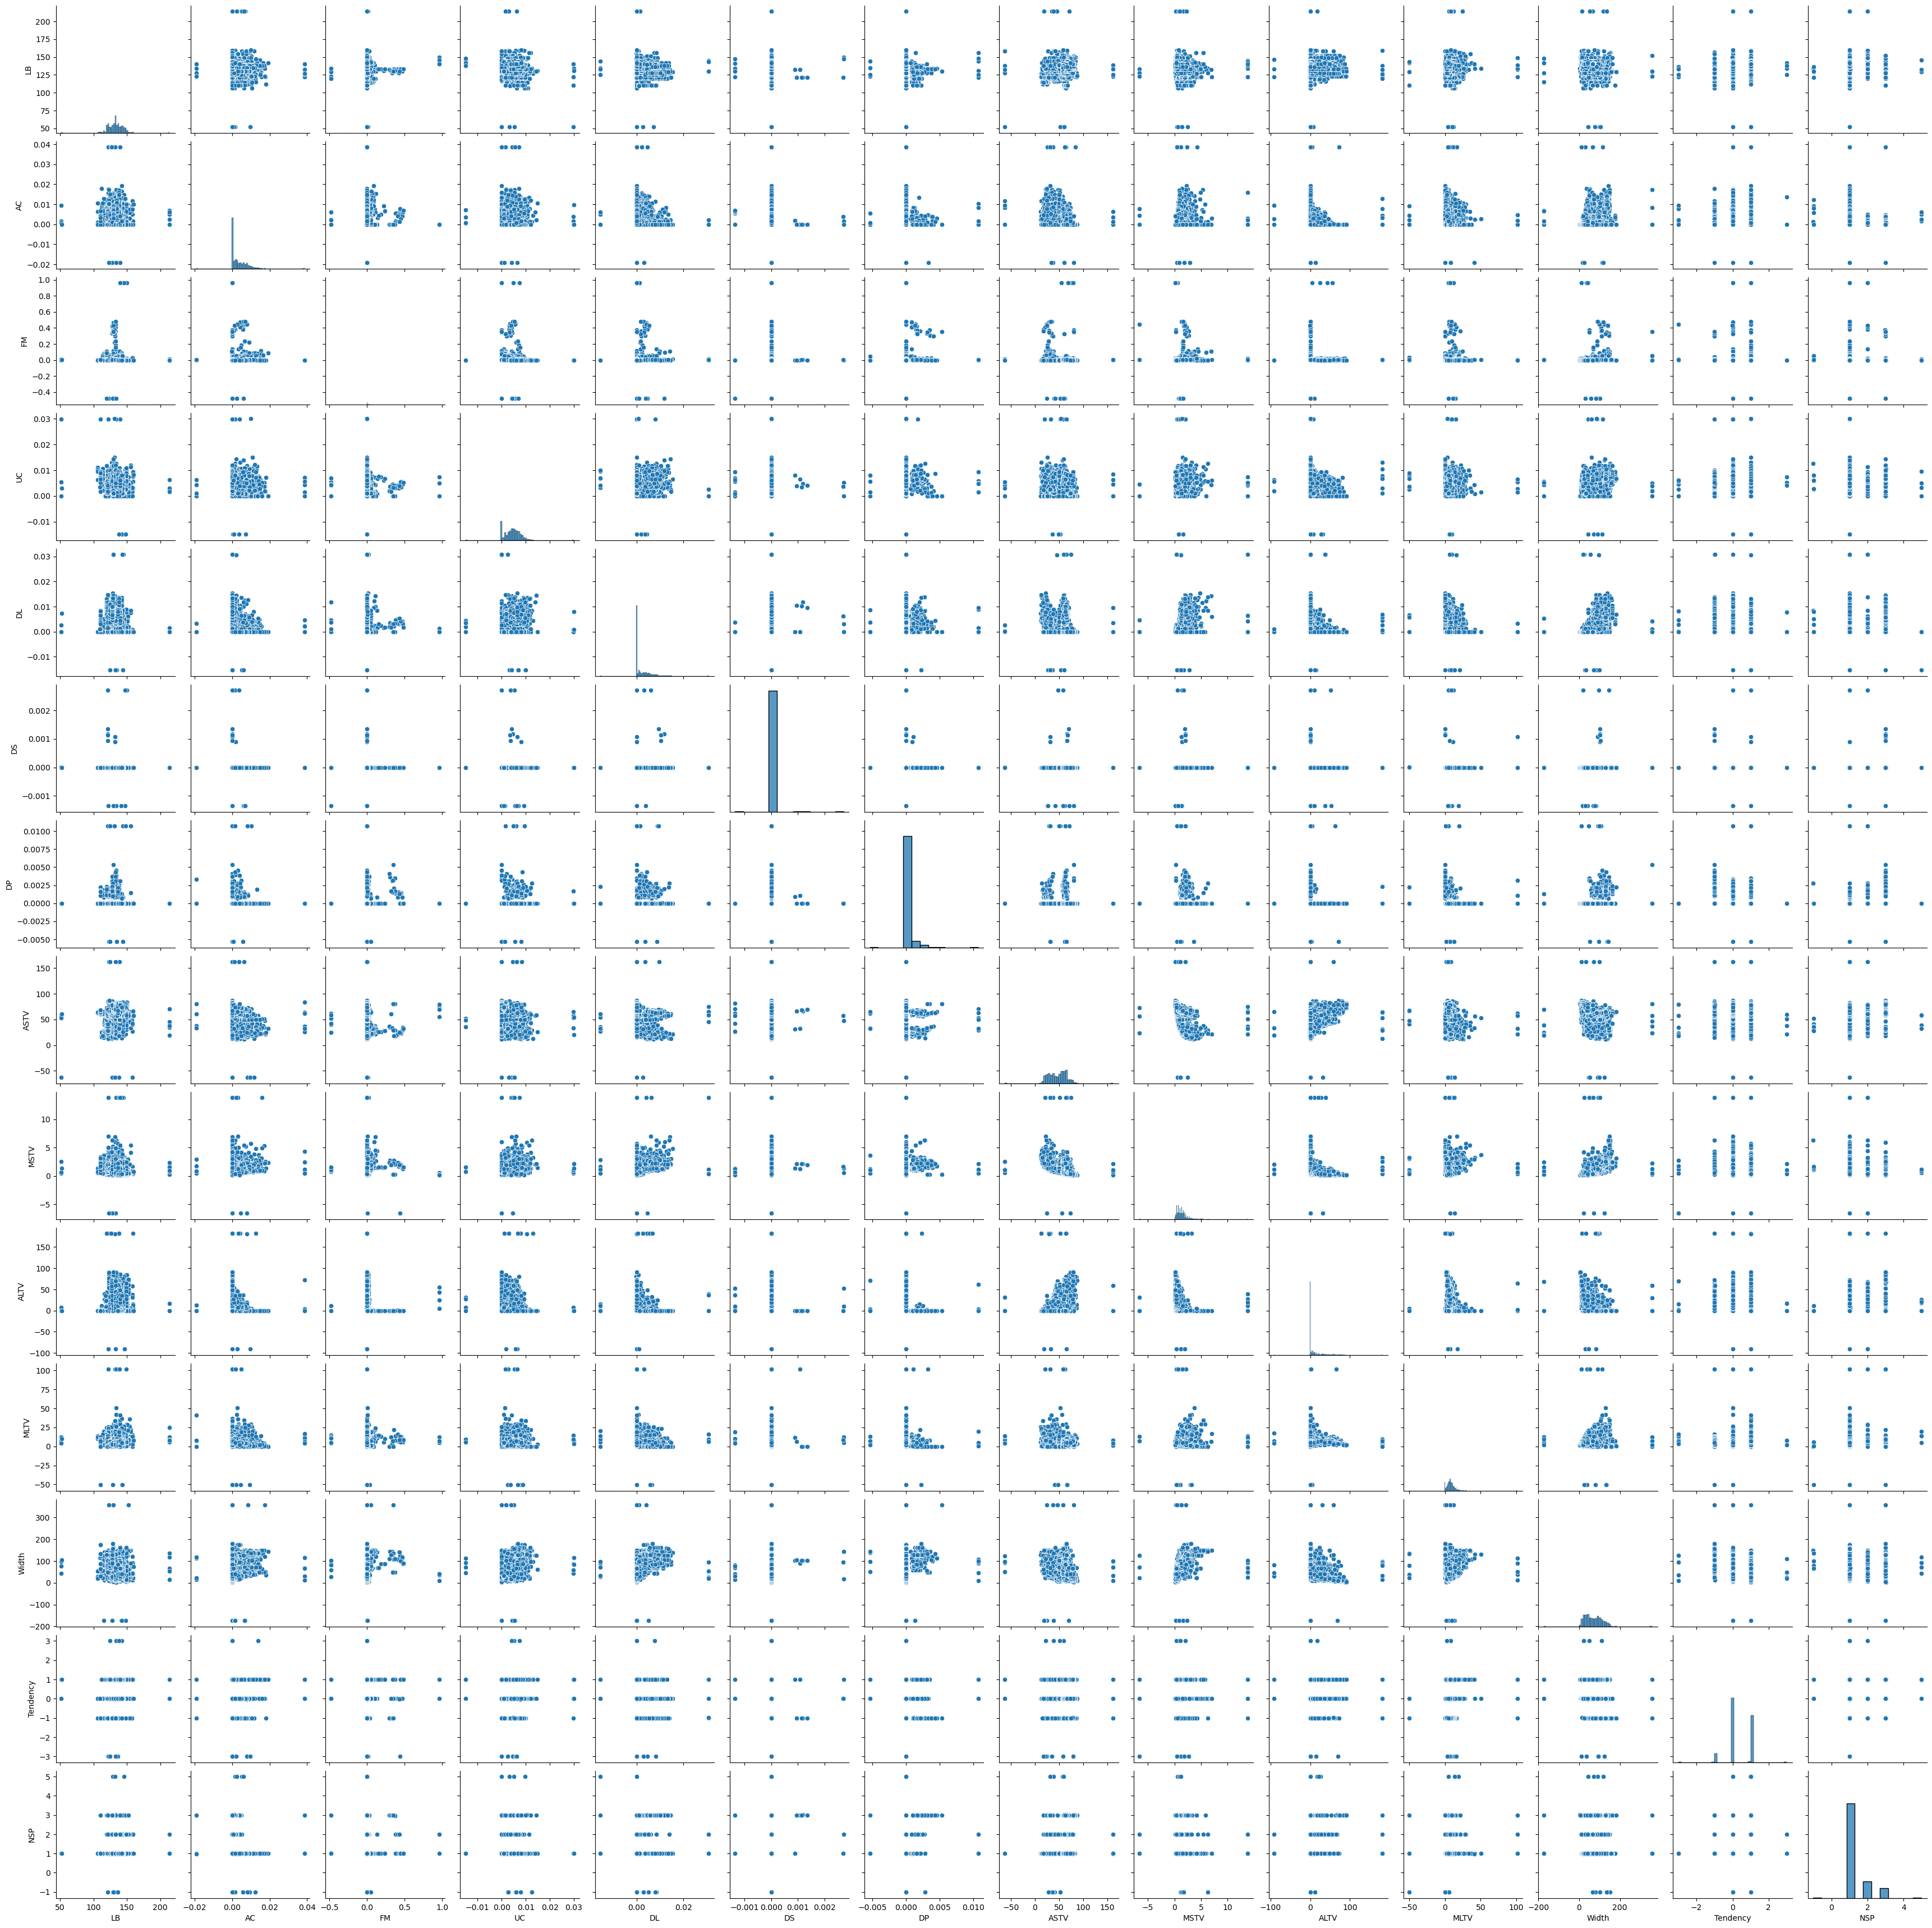

In [14]:
### pairplot
sns.pairplot(df)

In [15]:
#### missing values are handled
#### outliers are visible for DL,FM
#### correlation is strong among DL,ASTV,MSTV,ALTV but is weak between LB and variables like DS,DP
#### file now gives the data dynamics and relationships so is now ready for further analysis and decision making